In [1]:
import pandas as pd 
import numpy as np 
import xarray as xr 
from EDA import EDA_form_relation

In [3]:
cnt = 0
for k in np.linspace(2017,2025,9):
    k = int(k)
    ds = xr.open_dataset(f"C:\\Users\\l.ruizlozano\\Documents\\Project-Sentinel_data\\Rovaniemi\\data\\NetCDF\\L2A_Rovaniemi_winter_{k}_{k+1}.nc")
    #Convert to DataFrame
    df = ds.to_dataframe().reset_index()
    #Concat to a single DataFrame
    if cnt < 1:
        df_Sentinel = df.copy()
        cnt += 1
    else:
        df_Sentinel = pd.concat([df_Sentinel, df])
df_Sentinel.to_csv(r"C:\Users\l.ruizlozano\Documents\Project-Sentinel_data\Rovaniemi\df_Sentinel_bronze.csv", index=False)

In [5]:
df_Sentinel.head(15)

,t,y,x,crs,B03,B11,SCL
0,2017-11-02,7378475.0,442115.0,b'',6608.0,2503.0,8.0
1,2017-11-02,7378475.0,442125.0,b'',6556.0,2527.0,8.0
2,2017-11-02,7378475.0,442135.0,b'',6572.0,2527.0,8.0
3,2017-11-02,7378475.0,442145.0,b'',6500.0,2548.0,8.0
4,2017-11-02,7378475.0,442155.0,b'',6488.0,2548.0,8.0
5,2017-11-02,7378475.0,442165.0,b'',6640.0,2579.0,8.0
6,2017-11-02,7378475.0,442175.0,b'',6596.0,2579.0,8.0
7,2017-11-02,7378475.0,442185.0,b'',6424.0,2536.0,8.0
8,2017-11-02,7378475.0,442195.0,b'',6508.0,2536.0,8.0
9,2017-11-02,7378475.0,442205.0,b'',6608.0,2544.0,8.0


In [8]:
df_Sentinel["month"] = df_Sentinel.t.dt.month
df_Sentinel["year"] = df_Sentinel.t.dt.year

In [10]:
df_Sentinel.head(5)

,t,y,x,crs,B03,B11,SCL,month,year
0,2017-11-02,7378475.0,442115.0,b'',6608.0,2503.0,8.0,11,2017
1,2017-11-02,7378475.0,442125.0,b'',6556.0,2527.0,8.0,11,2017
2,2017-11-02,7378475.0,442135.0,b'',6572.0,2527.0,8.0,11,2017
3,2017-11-02,7378475.0,442145.0,b'',6500.0,2548.0,8.0,11,2017
4,2017-11-02,7378475.0,442155.0,b'',6488.0,2548.0,8.0,11,2017


In [25]:
df_Sentinel.groupby(["year", "month"])[["y", "x"]].value_counts()

year  month  y          x       
2017  11     7373975.0  442115.0     1
                        442125.0     1
                        442135.0     1
                        442145.0     1
                        442155.0     1
                                    ..
2026  4      7378475.0  444385.0    20
                        444395.0    20
                        444405.0    20
                        444415.0    20
                        444425.0    20
Name: count, Length: 4394544, dtype: int64

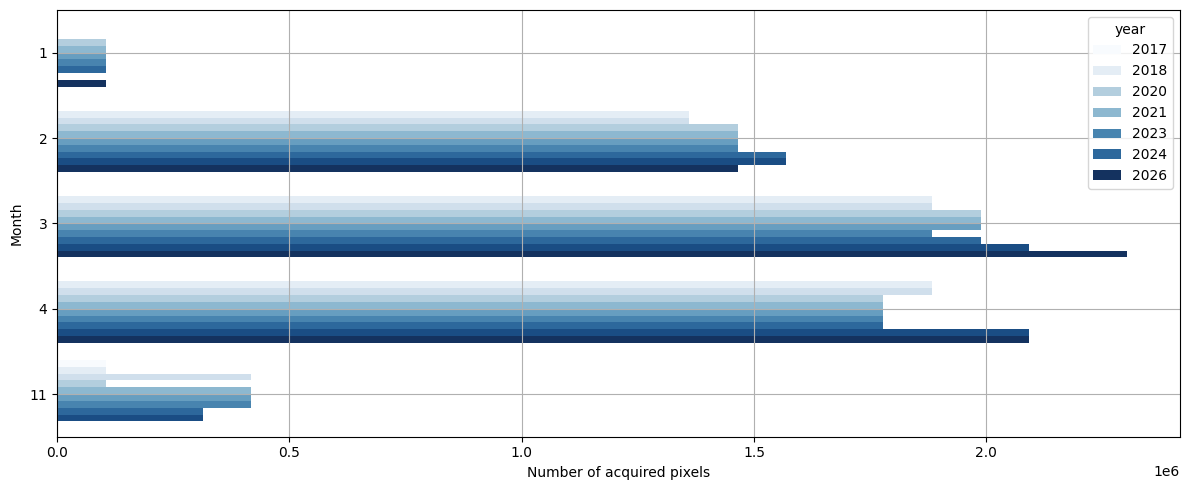

In [33]:
n_pixels = (
    df_Sentinel
    .groupby(["year", "month"])
    .size()
    .reset_index(name="n_pixels")
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.barplot(
    data=n_pixels,
    y="month",
    x="n_pixels",
    hue="year",
    orient="h",
    palette="Blues"
)

plt.grid()
plt.xlabel("Number of acquired pixels")
plt.ylabel("Month")
plt.tight_layout()

Text(95.72222222222221, 0.5, 'Year')

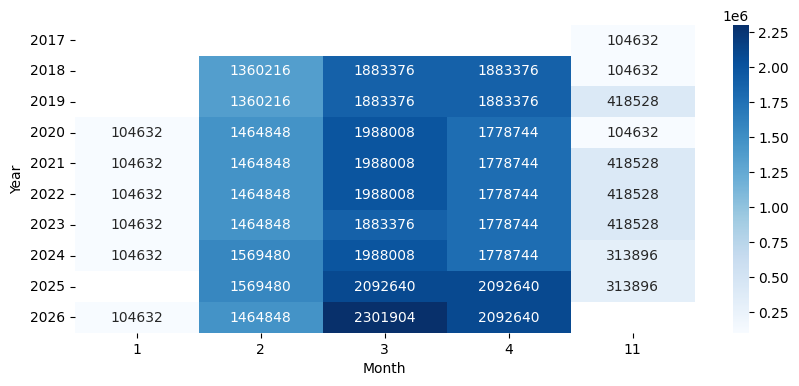

In [27]:
pivot = n_pixels.pivot(
    index="year",
    columns="month",
    values="n_pixels"
)

plt.figure(figsize=(10,4))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.xlabel("Month")
plt.ylabel("Year")

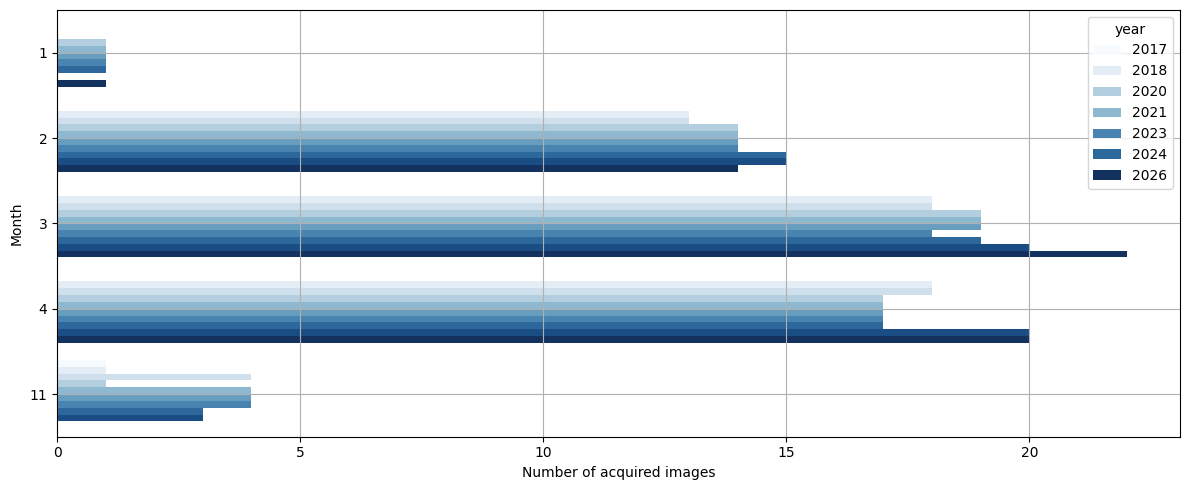

In [32]:
n_images = (
    df_Sentinel
    .groupby(["year", "month"])["t"]
    .nunique()
    .reset_index(name="n_images")
)



plt.figure(figsize=(12,5))

sns.barplot(
    data=n_images,
    y="month",
    x="n_images",
    hue="year",
    orient="h",
    palette="Blues"
)

plt.grid()
plt.xlabel("Number of acquired images")
plt.ylabel("Month")
plt.tight_layout()

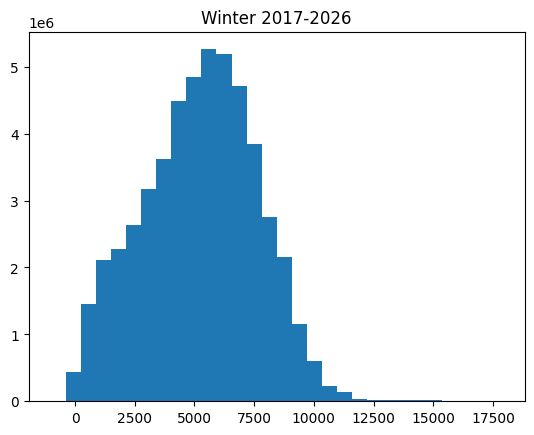

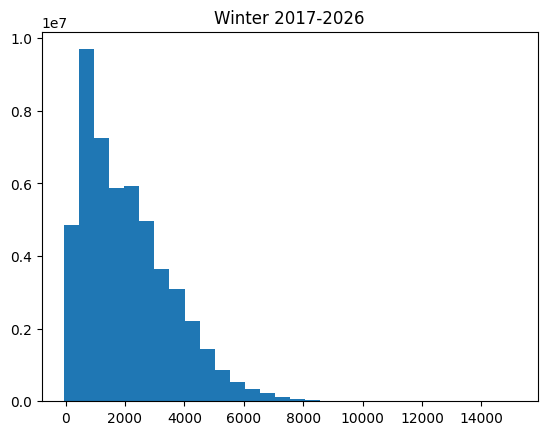

In [36]:
from pathlib import Path
for c in ["B03", "B11"]:
    figname = f"hist_{c}_winter_2017_2026.png"
    outfile = Path(r'C:\Users\l.ruizlozano\Documents\Project-Sentinel_data\Rovaniemi\figures\EDA\metric_and_relations') / figname
    
    plt.figure()
    plt.hist(df_Sentinel[c], bins=30)
    #sns.histplot(data=df_Sentinel, x = df_Sentinel[c], bins=30)
    plt.title("Winter 2017-2026")
    plt.savefig(outfile)

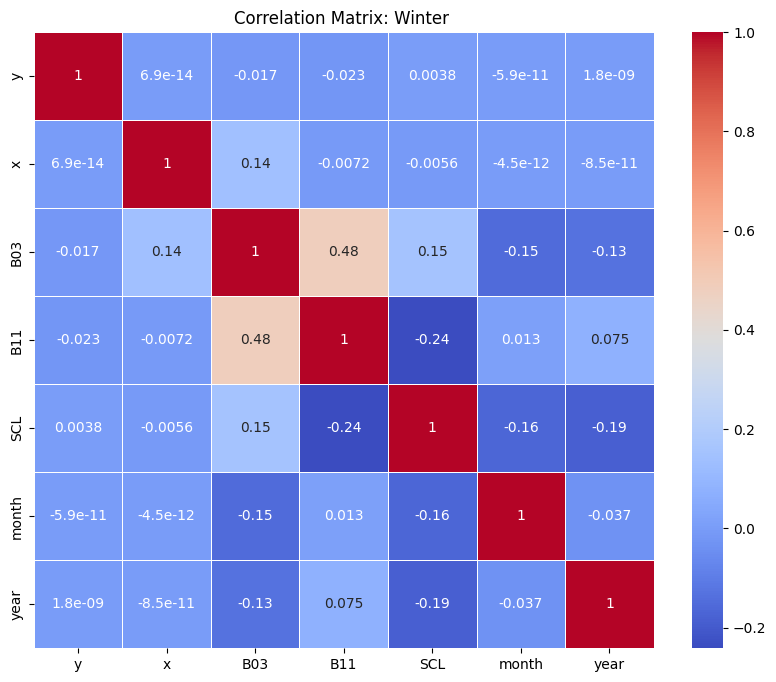

In [37]:
mat_corr =df_Sentinel.corr(numeric_only=True)
figname = f"corr_{c}_winter_2017_2026.png"
outfile = Path(r'C:\Users\l.ruizlozano\Documents\Project-Sentinel_data\Rovaniemi\figures\EDA\metric_and_relations') / figname

plt.figure(figsize=(10, 8))
sns.heatmap(mat_corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title(f"Correlation Matrix: Winter ")
plt.savefig(outfile)

In [4]:
#   1. Information on initial data
shape, info, describe, pd_metric, mask_cloud = EDA_form_relation(df_Sentinel, r'C:\Users\l.ruizlozano\Documents\Project-Sentinel_data\Rovaniemi\figures\EDA\metric_and_relations')
display(pd_metric)

<class 'pandas.core.frame.DataFrame'>
Index: 51269680 entries, 0 to 6277919
Data columns (total 7 columns):
 #   Column  Dtype         
---  ------  -----         
 0   t       datetime64[ns]
 1   y       float64       
 2   x       float64       
 3   crs     object        
 4   B03     float32       
 5   B11     float32       
 6   SCL     float32       
dtypes: datetime64[ns](1), float32(3), float64(2), object(1)
memory usage: 2.5+ GB


,Metric,Total,Percentage
0,Total pixels,51269680,100.000000
1,NaN,0,0.000000
2,Bad pixels,0,0.000000
3,Cloudy pixels,35293466,68.838865
